# Test Data Science : classification des demandes d'hébergement


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

## 1. Chargement des données

In [ ]:
from pathlib import Path

DATA_DIR = Path("data")

requests_train = pd.read_csv(
    DATA_DIR / "requests_train.csv",
    low_memory=False
)

requests_test = pd.read_csv(
    DATA_DIR / "requests_test.csv",
    low_memory=False
)

individuals_train = pd.read_csv(
    DATA_DIR / "individuals_train.csv",
    low_memory=False
)

individuals_test = pd.read_csv(
    DATA_DIR / "individuals_test.csv",
    low_memory=False
)

In [3]:
datasets = {
    "requests_train": requests_train,
    "requests_test": requests_test,
    "individuals_train": individuals_train,
    "individuals_test": individuals_test,
}

for name, df in datasets.items():
    print(f"{name}: {df.shape[0]} lignes et {df.shape[1]} colonnes")

requests_train: 238191 lignes et 24 colonnes
requests_test: 59548 lignes et 24 colonnes
individuals_train: 384133 lignes et 16 colonnes
individuals_test: 95641 lignes et 16 colonnes


In [4]:
display(requests_train.head())
display(individuals_train.head())

,request_id,animal_presence,answer_creation_date,child_situation,child_to_come,district,granted_number_of_nights,group_composition_id,group_composition_label,group_creation_date,group_id,group_main_requester_id,group_type,housing_situation_id,housing_situation_label,long_term_housing_request,number_of_underage,request_backoffice_creator_id,request_creation_date,requester_type,social_situation_id,town,victim_of_violence,victim_of_violence_type
0,130667d2964de43c511d0ead7ac66b33,f,2019-02-11 22:30:00,-1,NaN,85,1,10,man alone,2018-05-03 12:10:40.416,c62f692dcc3f31880dd3937369c6f9e1,56252a8182a732cad0d106328bf96a0b,individual,160,other,NaN,-1,eecd6110b7e9157e6423428b22a28159,2019-02-11 22:30:00,third party,9a84febc47fedaf2c81d7c755e9edc85,NaN,f,NaN
1,b1cd62fcf24eebb0f685d5eaf55317a8,f,2019-02-12 09:00:00,-1,NaN,85,1,10,man alone,2019-03-07 12:11:08.545,cbb3ae0239a3ca9a0441831bde02aaa3,b23d21c9973e5b74504a94eebe82fb75,individual,160,other,NaN,-1,eecd6110b7e9157e6423428b22a28159,2019-02-12 09:00:00,user,11f64f0547e855c5c59329b9edc63063,NaN,f,NaN
2,12cc0a18890bd4959fe42df3ae58838e,f,2019-02-01 21:00:00,-1,NaN,59,1,80,isolated child/underage,2019-03-13 12:54:15.887,a73d85877e940fd36ac23bb80ac7fbbe,5e063c21a61a5b38f8f21baebea86f50,individual,200,street,NaN,-1,686d962128c7622aa79ed91da13f5c77,2019-02-01 21:00:00,user,898ab2883f410f4c6fb042ef16329fbb,NaN,f,NaN
3,ae2d5b4dc181d29e430132f145da1556,f,2019-02-25 15:12:05.037,-1,NaN,50,2,20,woman alone,2018-10-09 14:37:29.773,5f69b8b928f84ce1e673740acb854af2,f46e831e036fe418d88d6d40ee4b0680,individual,170,NaN,NaN,-1,ec29519464c381a6630f4e480a0c000e,2019-02-25 15:12:05.037,user,3998c8e890ddc980527dd1af45dfa672,NaN,t,woman
4,d13a17ce36c832514fda2464e11c4a9f,f,2019-02-20 09:59:20.603,-1,NaN,93,2,60,group with child(ren),2018-10-02 10:47:36.931,df3a2364091c2aa9f90f2738f6b176f1,936ae1e1737f38e8f9ef3049805629f3,group,50,hotel paid by the emergency centre,NaN,-1,c8b5cc926b1d7212224a08baa9619518,2019-02-20 09:59:20.603,user,74a10d96eae43586bc3c46e89719b821,NaN,f,NaN


,request_id,individual_id,housing_situation_2_id,housing_situation_2_label,birth_month,birth_year,childcare_center_supervision,disabled_worker_certification,gender,individual_creation_date,individual_role,individual_role_2_id,individual_role_2_label,marital_status_id,marital_status_label,pregnancy
0,130667d2964de43c511d0ead7ac66b33,b24a8cfaaf3663bac45ca3bcd24f0b36,20,on the street,5,1977,NaN,NaN,male,2018-01-29,isolated person,30,isolated adult,10,single person,f
1,b1cd62fcf24eebb0f685d5eaf55317a8,eef783d1bda82661a751c12c34aff8c2,20,on the street,5,1980,NaN,NaN,male,2019-03-07,NaN,30,isolated adult,-1,NaN,f
2,12cc0a18890bd4959fe42df3ae58838e,927b6fa58d6be263c411332835b11fec,20,on the street,1,2003,NaN,NaN,male,2019-03-13,NaN,10,isolated underage/child,-1,NaN,f
3,ae2d5b4dc181d29e430132f145da1556,94181d5cf4a56cc84d12677df84e2e03,20,on the street,7,1986,NaN,NaN,female,2018-10-09,NaN,30,isolated adult,-1,NaN,f
4,d13a17ce36c832514fda2464e11c4a9f,e79d2e3f9ace50049f1796c098008c13,35,hotel paid by the emergency structure,9,1980,NaN,NaN,female,2017-06-22,husband/spouse,1,partner,-1,NaN,f


In [5]:
print("REQUESTS TRAIN")
requests_train.info()

print("\nINDIVIDUALS TRAIN")
individuals_train.info()

REQUESTS TRAIN
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238191 entries, 0 to 238190
Data columns (total 24 columns):
 #   Column                         Non-Null Count   Dtype 
---  ------                         --------------   ----- 
 0   request_id                     238191 non-null  object
 1   animal_presence                238191 non-null  object
 2   answer_creation_date           238191 non-null  object
 3   child_situation                238191 non-null  int64 
 4   child_to_come                  92244 non-null   object
 5   district                       238191 non-null  int64 
 6   granted_number_of_nights       238191 non-null  int64 
 7   group_composition_id           238191 non-null  int64 
 8   group_composition_label        238191 non-null  object
 9   group_creation_date            238191 non-null  object
 10  group_id                       238191 non-null  object
 11  group_main_requester_id        238191 non-null  object
 12  group_type                   

In [6]:
print("REQUESTS TEST")
requests_test.info()

print("\nINDIVIDUALS TEST")
individuals_test.info()

REQUESTS TEST
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59548 entries, 0 to 59547
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   request_id                     59548 non-null  object
 1   animal_presence                59548 non-null  object
 2   answer_creation_date           59548 non-null  object
 3   child_situation                59548 non-null  int64 
 4   child_to_come                  23209 non-null  object
 5   district                       59548 non-null  int64 
 6   granted_number_of_nights       59548 non-null  int64 
 7   group_composition_id           59548 non-null  int64 
 8   group_composition_label        59547 non-null  object
 9   group_creation_date            59547 non-null  object
 10  group_id                       59548 non-null  object
 11  group_main_requester_id        59548 non-null  object
 12  group_type                     59547 non-null 

## 2. Correction des types


In [7]:
def parse_dates(df, columns):
    df = df.copy()
    for column in columns:
        df[column] = pd.to_datetime(df[column], errors="coerce", format="mixed") #mixed:plus formats #coerce ; transforme format invalide en NAT (nan de date)
    return df

In [8]:
REQUEST_DATE_COLUMNS = ["answer_creation_date", "group_creation_date", "request_creation_date"]

requests_train = parse_dates(requests_train, REQUEST_DATE_COLUMNS)
requests_test = parse_dates(requests_test, REQUEST_DATE_COLUMNS)

requests_train[REQUEST_DATE_COLUMNS].dtypes

answer_creation_date     datetime64[ns]
group_creation_date      datetime64[ns]
request_creation_date    datetime64[ns]
dtype: object

In [9]:
individuals_train["individual_creation_date"] = pd.to_datetime(
    individuals_train["individual_creation_date"], errors="coerce", format="mixed"
)
individuals_test["individual_creation_date"] = pd.to_datetime(
    individuals_test["individual_creation_date"], errors="coerce", format="mixed"
)

individuals_train["individual_creation_date"].dtype

dtype('<M8[ns]')

In [10]:
print("REQUESTS TRAIN")
requests_train.info()

print("\nINDIVIDUALS TRAIN")
individuals_train.info()

REQUESTS TRAIN
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238191 entries, 0 to 238190
Data columns (total 24 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   request_id                     238191 non-null  object        
 1   animal_presence                238191 non-null  object        
 2   answer_creation_date           238191 non-null  datetime64[ns]
 3   child_situation                238191 non-null  int64         
 4   child_to_come                  92244 non-null   object        
 5   district                       238191 non-null  int64         
 6   granted_number_of_nights       238191 non-null  int64         
 7   group_composition_id           238191 non-null  int64         
 8   group_composition_label        238191 non-null  object        
 9   group_creation_date            238191 non-null  datetime64[ns]
 10  group_id                       238191 non-null  objec

## 3. Valeurs manquantes dans `requests`

In [11]:
def missing_values_table(df):
    missing = df.isnull().sum()
    percentage = (missing / len(df) * 100).round(2)

    result = pd.DataFrame({
        "Nombre de valeurs manquantes": missing,
        "Pourcentage": percentage,
    })

    return result[result["Nombre de valeurs manquantes"] > 0].sort_values("Pourcentage", ascending=False)

In [12]:
display(missing_values_table(requests_train))

,Nombre de valeurs manquantes,Pourcentage
victim_of_violence_type,234175,98.31
long_term_housing_request,165556,69.51
town,159959,67.16
child_to_come,145947,61.27
housing_situation_label,16748,7.03


In [13]:
display(missing_values_table(requests_test))

,Nombre de valeurs manquantes,Pourcentage
victim_of_violence_type,58580,98.37
long_term_housing_request,41257,69.28
town,39729,66.72
child_to_come,36339,61.02
housing_situation_label,4189,7.03
group_type,1,0.00
group_creation_date,1,0.00
group_composition_label,1,0.00
victim_of_violence,1,0.00


### Comprendre la signification des valeurs manquantes

In [14]:
pd.crosstab(
    requests_train["victim_of_violence"],
    requests_train["victim_of_violence_type"].isna(),
    margins=True,
)

victim_of_violence_type,False,True,All
victim_of_violence,,,
f,0,233881,233881
t,4016,294,4310
All,4016,234175,238191


In [15]:
pd.crosstab(
    requests_train["child_to_come"],
    requests_train["group_type"],
    dropna=False,
    margins=True,
)

group_type,group,individual,All
child_to_come,,,
f,22774,63104,85878.0
t,4054,2312,6366.0
NaN,40311,105636,NaN
All,67139,171052,238191.0


**Décisions retenues** :

- `victim_of_violence_type` : quand `victim_of_violence = "f"`, l'absence du type signifie qu'aucune
  violence n'a été déclarée → `"no_violence"`. Quand `victim_of_violence = "t"` et le type est
  manquant, la violence est déclarée mais le type n'est pas renseigné → `"unknown"`.
- `long_term_housing_request`, `town`, `child_to_come`, `housing_situation_label` : une valeur
  manquante ne permet pas de conclure à une réponse négative → `"unknown"`, pour ne pas inventer
  une valeur comme `"f"` quand l'information réelle est inconnue.
- `group_type`, `group_composition_label`, `victim_of_violence` : quelques lignes manquantes dans
  `requests_test` uniquement → complétées par `"unknown"` pour garder une logique identique
  train/test.


In [16]:
VICTIM_TYPE_COLUMN = "victim_of_violence_type"
UNKNOWN_FILL_COLUMNS = [
    "long_term_housing_request",
    "town",
    "child_to_come",
    "housing_situation_label",
    "group_type",
    "group_composition_label",
    "victim_of_violence",
]


def fill_violence_type(df):
    df = df.copy()
    no_violence = df["victim_of_violence"] == "f"
    df.loc[no_violence & df[VICTIM_TYPE_COLUMN].isna(), VICTIM_TYPE_COLUMN] = "no_violence"
    df[VICTIM_TYPE_COLUMN] = df[VICTIM_TYPE_COLUMN].fillna("unknown")
    return df

## 4. Identifiants numériques codés en `-1`

y'a des colonnes ou on a -1 à la place de Nan 

In [17]:
def check_negative_values(df, dataset_name):
    print(f"\n--- {dataset_name} ---")
    numeric_columns = df.select_dtypes(include="number").columns
    for column in numeric_columns:
        negative_count = (df[column] < 0).sum()
        if negative_count > 0:
            print(f"{column} : {negative_count} valeur(s) négative(s)")


check_negative_values(requests_train, "requests_train")
check_negative_values(requests_test, "requests_test")
check_negative_values(individuals_train, "individuals_train")
check_negative_values(individuals_test, "individuals_test")


--- requests_train ---
child_situation : 228080 valeur(s) négative(s)
number_of_underage : 170220 valeur(s) négative(s)

--- requests_test ---
child_situation : 56999 valeur(s) négative(s)
group_composition_id : 1 valeur(s) négative(s)
number_of_underage : 42478 valeur(s) négative(s)

--- individuals_train ---
individual_role_2_id : 55 valeur(s) négative(s)
marital_status_id : 102338 valeur(s) négative(s)

--- individuals_test ---
birth_month : 1 valeur(s) négative(s)
birth_year : 1 valeur(s) négative(s)
individual_role_2_id : 13 valeur(s) négative(s)
marital_status_id : 24872 valeur(s) négative(s)


In [18]:
pd.crosstab(
    requests_train["number_of_underage"],
    requests_train["group_type"],
    margins=True,
)

group_type,group,individual,All
number_of_underage,,,
-1,48598,121622,170220
0,2406,48319,50725
1,7351,564,7915
2,4610,357,4967
3,2907,107,3014
4,760,35,795
5,351,30,381
6,79,12,91
7,68,2,70


`child_situation`, `district`, `group_composition_id`, `housing_situation_id` (côté `requests`)
et `individual_role_2_id`, `marital_status_id` (côté `individuals`) sont des **identifiants
catégoriels**, pas des quantités : `-1` y est converti en la catégorie `"unknown"`.

`birth_month` et `birth_year` (côté `individuals`) sont de vraies valeurs numériques : `-1` y est
remplacé par `NaN`.

**Cas particulier : `number_of_underage`.** Cette colonne est la seule vraie variable quantitative
de `requests` (nombre d'enfants mineurs dans le groupe). Le croisement avec `group_type` montre
que `-1` correspond très majoritairement aux demandes où `group_type = "individual"` (une seule
personne, pour qui la notion de "nombre d'enfants dans le groupe" n'a pas la même logique que
pour `group_type = "group"`).
On remplace donc `-1` par `NaN`, en conservant un indicateur binaire `number_of_underage_missing`
pour ne pas perdre cette information pour le modèle.


In [19]:
REQUEST_CATEGORICAL_ID_COLUMNS = ["child_situation", "district", "group_composition_id", "housing_situation_id"]
INDIVIDUAL_CATEGORICAL_ID_COLUMNS = ["individual_role_2_id", "marital_status_id"]


def clean_categorical_ids(df, columns):
    df = df.copy()
    for column in columns:
        df[column] = df[column].astype(str).replace("-1", "unknown")
    return df


def clean_number_of_underage(df):
    df = df.copy()
    df["number_of_underage_missing"] = (df["number_of_underage"] == -1).astype(int)
    df["number_of_underage"] = df["number_of_underage"].replace(-1, np.nan)
    return df

## 5. Table `individuals` : valeurs manquantes

In [20]:
# Lister uniquement les colonnes contenant des valeurs manquantes

missing_columns = individuals_test.isna().sum()

missing_columns = missing_columns[missing_columns > 0].sort_values(
    ascending=False
)

display(
    pd.DataFrame({
        "nombre_de_nan": missing_columns,
        "pourcentage_de_nan": (
            missing_columns / len(individuals_train) * 100
        ).round(2)
    })
)

,nombre_de_nan,pourcentage_de_nan
childcare_center_supervision,94187,24.52
individual_role,74938,19.51
disabled_worker_certification,62986,16.40
marital_status_label,24872,6.47
individual_creation_date,4942,1.29
individual_role_2_label,13,0.00
pregnancy,4,0.00
gender,1,0.00


In [21]:
individual_columns_to_check = [
    "childcare_center_supervision",
    "individual_role",
    "disabled_worker_certification",
    "marital_status_label",
    "individual_creation_date",
    "individual_role_2_label",
    "gender",
    "pregnancy",
]

for column in individual_columns_to_check:
    print(f"\n--- {column} ---")
    print(individuals_train[column].value_counts(dropna=False).head(15))


--- childcare_center_supervision ---
childcare_center_supervision
NaN    378254
f        3021
t        2858
Name: count, dtype: int64

--- individual_role ---
individual_role
NaN                301043
isolated person     35900
child               20691
husband/spouse      10471
isolated parent      7893
partner              7603
family member         444
other                  88
Name: count, dtype: int64

--- disabled_worker_certification ---
disabled_worker_certification
NaN    254741
f      126270
t        3122
Name: count, dtype: int64

--- marital_status_label ---
marital_status_label
single person           201444
NaN                     102338
married                  39961
cohabitation             31098
separated                 3580
marital relationship      2879
divorced                  2013
widowed                    652
civil partner              168
Name: count, dtype: int64

--- individual_creation_date ---
individual_creation_date
NaT           19700
2018-03-19     586

**Décisions retenues**, en distinguant enfant (`individual_role_2_label` dans les rôles
enfants) et adulte :

- `childcare_center_supervision` : enfant + manquant → `"unknown"` (info réellement inconnue) ;
  adulte + manquant → `"not_applicable"` (la question ne le concerne pas).
- `disabled_worker_certification`, `marital_status_label` : enfant + manquant → `"not_applicable"` ;
  sinon → `"unknown"`.
- `pregnancy` : homme + manquant → `"not_applicable"` ; sinon → `"unknown"`.
- `individual_role`, `individual_role_2_label`, `gender` : `"unknown"`.


In [22]:
CHILD_ROLES = ["child/underage with family", "isolated underage/child"]


def clean_individuals(df):
    df = df.copy()

    for column in ["birth_month", "birth_year"]:
        df[column] = df[column].replace(-1, np.nan)

    df = clean_categorical_ids(df, INDIVIDUAL_CATEGORICAL_ID_COLUMNS)

    is_child = df["individual_role_2_label"].isin(CHILD_ROLES)

    # 1. Suivi par un centre pour l'enfance
    df.loc[is_child & df["childcare_center_supervision"].isna(), "childcare_center_supervision"] = "unknown"
    df.loc[~is_child & df["childcare_center_supervision"].isna(), "childcare_center_supervision"] = "not_applicable"

    # 2. Certification de travailleur handicapé
    df.loc[is_child & df["disabled_worker_certification"].isna(), "disabled_worker_certification"] = "not_applicable"
    df["disabled_worker_certification"] = df["disabled_worker_certification"].fillna("unknown")

    # 3. Situation matrimoniale
    df.loc[is_child & df["marital_status_label"].isna(), "marital_status_label"] = "not_applicable"
    df["marital_status_label"] = df["marital_status_label"].fillna("unknown")

    # 4. Grossesse
    df.loc[(df["gender"] == "male") & df["pregnancy"].isna(), "pregnancy"] = "not_applicable"
    df["pregnancy"] = df["pregnancy"].fillna("unknown")

    # 5-7. Rôles et genre
    df["individual_role"] = df["individual_role"].fillna("unknown")
    df["individual_role_2_label"] = df["individual_role_2_label"].fillna("unknown")
    df["gender"] = df["gender"].fillna("unknown")

    # 8. Date de création (piège de format mixte, cf. section 2)
    df["individual_creation_date"] = pd.to_datetime(df["individual_creation_date"], errors="coerce", format="mixed")
    df["individual_creation_date_missing"] = df["individual_creation_date"].isna().astype(int)

    return df

## 6. Pipeline de nettoyage consolidé

Pour garantir que **train et test reçoivent exactement le même traitement** (et éviter la
duplication de code), tout le nettoyage de `requests` est regroupé dans une seule fonction
`clean_requests`, appliquée une fois à chaque jeu de données. `clean_individuals` a été définie
juste au-dessus.

In [23]:
def clean_requests(df):
    df = df.copy()
    df = parse_dates(df, REQUEST_DATE_COLUMNS)
    df = clean_number_of_underage(df)
    df = fill_violence_type(df)
    df = clean_categorical_ids(df, REQUEST_CATEGORICAL_ID_COLUMNS)
    for column in UNKNOWN_FILL_COLUMNS:
        df[column] = df[column].fillna("unknown")
    return df

In [24]:
requests_train = clean_requests(requests_train)
requests_test = clean_requests(requests_test)
individuals_train = clean_individuals(individuals_train)
individuals_test = clean_individuals(individuals_test)

### Vérification post-nettoyage

In [25]:
display(missing_values_table(requests_train))
display(missing_values_table(requests_test))
display(missing_values_table(individuals_train))
display(missing_values_table(individuals_test))

,Nombre de valeurs manquantes,Pourcentage
number_of_underage,170220,71.46


,Nombre de valeurs manquantes,Pourcentage
number_of_underage,42478,71.33
group_creation_date,1,0.00


,Nombre de valeurs manquantes,Pourcentage
individual_creation_date,19700,5.13


,Nombre de valeurs manquantes,Pourcentage
individual_creation_date,4942,5.17
birth_month,1,0.00
birth_year,1,0.00


Il ne reste que de la vraie donnée manquante, assumée  :

- `number_of_underage` : NaN pour les demandes où `group_type = "individual"` (cf. section 4),
  avec le flag `number_of_underage_missing` conservé pour le modèle.
- `individual_creation_date` : quelques individus sans date de création enregistrée.
- `birth_month` / `birth_year` : 1 valeur chacune dans `individuals_test` (donnée réellement
  absente, pas une convention `-1`).
- `group_creation_date` : 1 valeur dans `requests_test`.

Aucune de ces colonnes ne contient plus de `-1` déguisé en valeur numérique.

In [26]:
check_negative_values(requests_train, "requests_train")
check_negative_values(requests_test, "requests_test")
check_negative_values(individuals_train, "individuals_train")
check_negative_values(individuals_test, "individuals_test")


--- requests_train ---

--- requests_test ---

--- individuals_train ---

--- individuals_test ---


## 7. Doublons et identifiants

In [27]:
print("Doublons complets :")
print("requests_train :", requests_train.duplicated().sum())
print("requests_test :", requests_test.duplicated().sum())
print("individuals_train :", individuals_train.duplicated().sum())
print("individuals_test :", individuals_test.duplicated().sum())

Doublons complets :
requests_train : 0
requests_test : 0
individuals_train : 0
individuals_test : 0


In [28]:
print("request_id dupliqués dans requests_train :", requests_train["request_id"].duplicated().sum())
print("request_id dupliqués dans requests_test :", requests_test["request_id"].duplicated().sum())

request_id dupliqués dans requests_train : 0
request_id dupliqués dans requests_test : 0


Aucun doublon, et `request_id` est bien une clé unique dans `requests_train`/`requests_test`, ce qui confirme qu'une ligne y correspond bien à une seule demande.

## 8. Analyse de la variable cible

In [29]:
class_counts = requests_train["granted_number_of_nights"].value_counts().sort_index()
class_percentages = (
    requests_train["granted_number_of_nights"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

target_distribution = pd.DataFrame({"Nombre": class_counts, "Pourcentage": class_percentages})
display(target_distribution)

,Nombre,Pourcentage
granted_number_of_nights,,
0,116542,48.93
1,81723,34.31
2,37340,15.68
3,2586,1.09


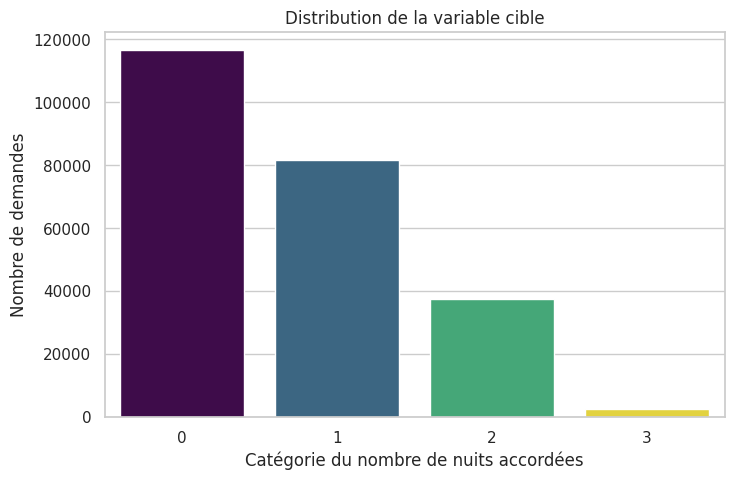

In [30]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=requests_train,
    x="granted_number_of_nights",
    hue="granted_number_of_nights",
    palette="viridis",
    legend=False,
)
plt.title("Distribution de la variable cible")
plt.xlabel("Catégorie du nombre de nuits accordées")
plt.ylabel("Nombre de demandes")
plt.show()

## 9. Point d'attention : fuite de données (data leakage)



In [31]:
LEAKAGE_COLUMNS = ["answer_creation_date"]

## 11. Export des données nettoyées

In [ ]:
requests_train.to_csv(
    DATA_DIR / "requests_train_clean.csv",
    index=False
)

requests_test.to_csv(
    DATA_DIR / "requests_test_clean.csv",
    index=False
)

individuals_train.to_csv(
    DATA_DIR / "individuals_train_clean.csv",
    index=False
)

individuals_test.to_csv(
    DATA_DIR / "individuals_test_clean.csv",
    index=False
)

print("Les quatre datasets ont été exportés avec succès dans le dossier data.")

Les quatre datasets ont été exportés avec succès.
